In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


In [24]:
df=pd.read_csv("/content/drive/MyDrive/Data Science/Dataset/Fraud_Analysis_Dataset.csv")

# EDA and Preprocessing

In [25]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [26]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
11137,7,DEBIT,6393.71,C1331144930,433084.38,426690.68,C684896216,478421.00,210535.25,0
11138,7,CASH_OUT,298799.54,C932023579,426690.68,127891.14,C1761353343,704355.36,5270364.19,0
11139,7,CASH_OUT,423159.63,C61395726,127891.14,0.00,C1298316171,610479.00,749621.53,0
11140,7,PAYMENT,1094.03,C1224570697,13918.00,12823.97,M983553548,0.00,0.00,0
11141,7,PAYMENT,9235.58,C1637966097,39963.00,30727.42,M609545864,0.00,0.00,0


In [27]:
df.shape

(11142, 10)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [29]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.000000,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,1.114200e+04,11142.000000
mean,8.717645,2.131915e+05,9.241173e+05,8.249576e+05,8.883541e+05,1.103211e+06,0.102495
std,16.067479,7.600650e+05,2.143004e+06,2.089894e+06,2.601376e+06,2.982447e+06,0.303312
min,1.000000,2.390000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,2.000000,4.946618e+03,4.270000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6.000000,1.676126e+04,2.816950e+04,4.420605e+03,0.000000e+00,0.000000e+00,0.000000
75%,7.000000,1.543366e+05,3.040855e+05,1.114126e+05,2.711555e+05,3.186374e+05,0.000000
max,95.000000,1.000000e+07,1.990000e+07,1.300000e+07,3.300000e+07,3.460000e+07,1.000000


In [30]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [31]:
df.dtypes

,0
step,int64
type,object
amount,float64
nameOrig,object
oldbalanceOrg,float64
newbalanceOrig,float64
nameDest,object
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64


In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.nunique()

,0
step,95
type,5
amount,10565
nameOrig,11142
oldbalanceOrg,7806
newbalanceOrig,5914
nameDest,7508
oldbalanceDest,4531
newbalanceDest,2030
isFraud,2


In [34]:
df['isFraud'].value_counts()

,count
isFraud,
0,10000
1,1142


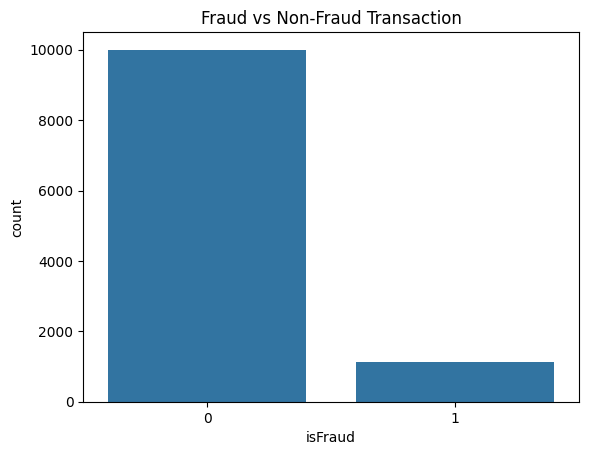

In [35]:
sns.countplot(x='isFraud',data=df)
plt.title("Fraud vs Non-Fraud Transaction")
plt.show()

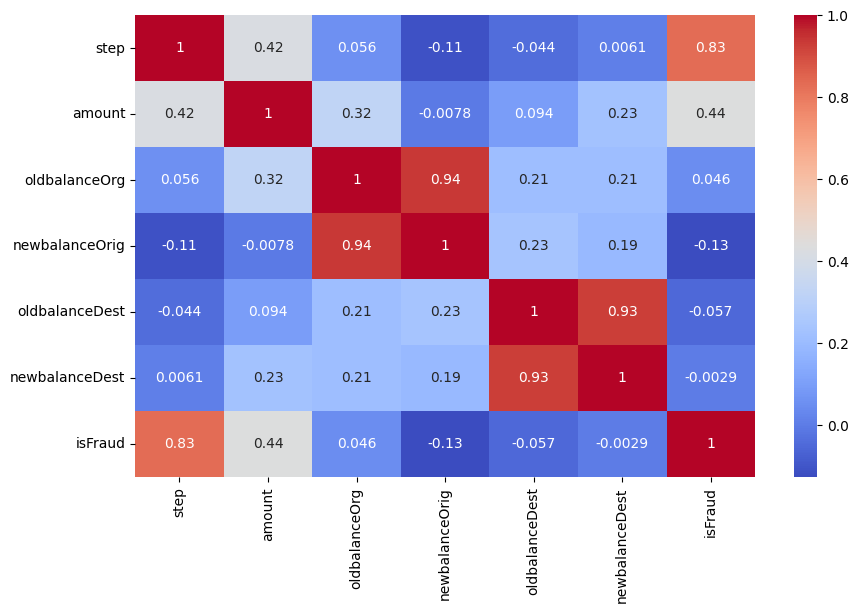

In [36]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [37]:
df.drop(columns=['nameOrig','nameDest','step'],axis=1,inplace=True)

These 2 features is not very useful for prediction so we delete them.

In [38]:
#creating new features
df['sender_balance_diff']=(df['oldbalanceOrg'] - df['newbalanceOrig'])
df['receiver_balance_diff']=(df['newbalanceDest'] - df['oldbalanceDest'])

In [39]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_diff,receiver_balance_diff
0,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0
1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0
2,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0
3,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0
4,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0


In [40]:
df['sender_balance_zero']=(df['newbalanceOrig']==0).astype(int)
df['receiver_balance_zero']=(df['newbalanceDest']==0).astype(int)

fraud accounts often go to zero after a trasaction so we check that.

In [41]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_diff,receiver_balance_diff,sender_balance_zero,receiver_balance_zero
0,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,1,1
1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,1,1
2,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,1,1
3,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,1,1
4,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,1,1


In [42]:
numeric_cols=df.select_dtypes(include=[np.number]).columns.tolist()
categoric_cols=df.select_dtypes(exclude=[np.number]).columns.tolist()

In [43]:
numeric_cols

['amount',
 'oldbalanceOrg',
 'newbalanceOrig',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'sender_balance_diff',
 'receiver_balance_diff',
 'sender_balance_zero',
 'receiver_balance_zero']

In [44]:
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,sender_balance_diff,receiver_balance_diff,sender_balance_zero,receiver_balance_zero
0,TRANSFER,181.0,181.0,0.0,0.0,0.0,1,181.0,0.0,1,1
1,CASH_OUT,181.0,181.0,0.0,21182.0,0.0,1,181.0,-21182.0,1,1
2,TRANSFER,2806.0,2806.0,0.0,0.0,0.0,1,2806.0,0.0,1,1
3,CASH_OUT,2806.0,2806.0,0.0,26202.0,0.0,1,2806.0,-26202.0,1,1
4,TRANSFER,20128.0,20128.0,0.0,0.0,0.0,1,20128.0,0.0,1,1


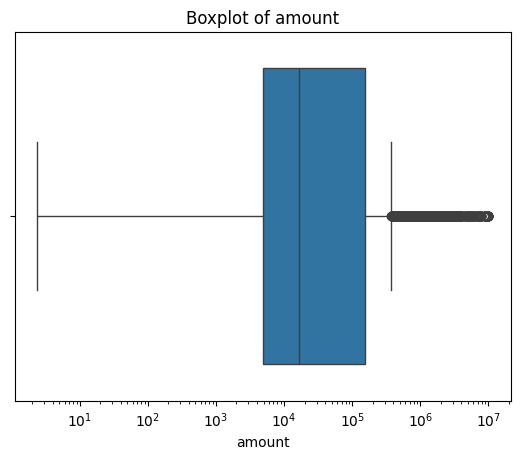

In [45]:
sns.boxplot(x=df['amount'])
plt.xscale('log')
plt.title('Boxplot of amount')
plt.show()

This plot shows that most transaction amounts are small, and only a few transactions have very large values.

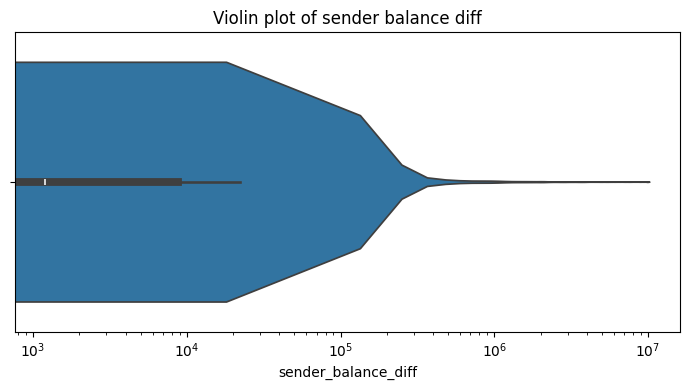

In [46]:
plt.figure(figsize=(7,4))
sns.violinplot(x=df['sender_balance_diff'])
plt.xscale('log')
plt.title('Violin plot of sender balance diff')
plt.tight_layout()
plt.show()

This graph helps us see that most sender balance changes are low, but there are some big outliers.

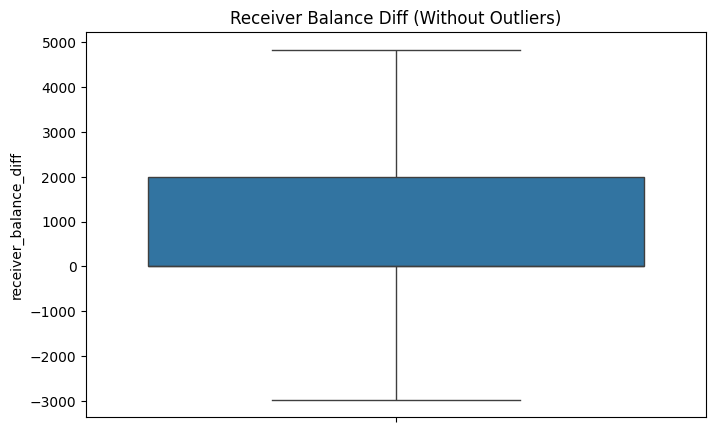

In [47]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['receiver_balance_diff'],
    showfliers=False
)

plt.title("Receiver Balance Diff (Without Outliers)")
plt.show()

Receiver balance differences contain significant outliers, while the majority of transactions are concentrated near zero.

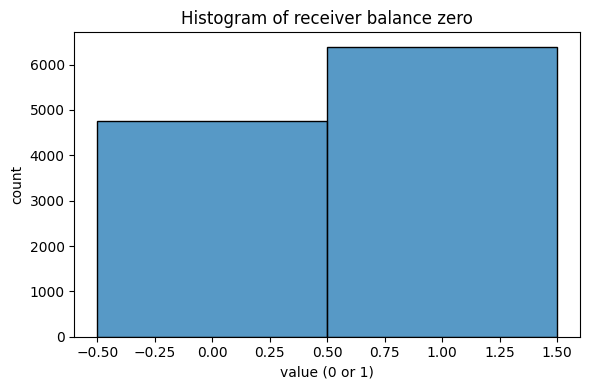

In [48]:
plt.figure(figsize=(6,4))
sns.histplot(df['receiver_balance_zero'],bins=2,discrete=2)
plt.title('Histogram of receiver balance zero')
plt.xlabel('value (0 or 1)')
plt.ylabel('count')
plt.tight_layout()
plt.show()

This histogram shows how many destination accounts start with zero balance versus a non-zero balance.

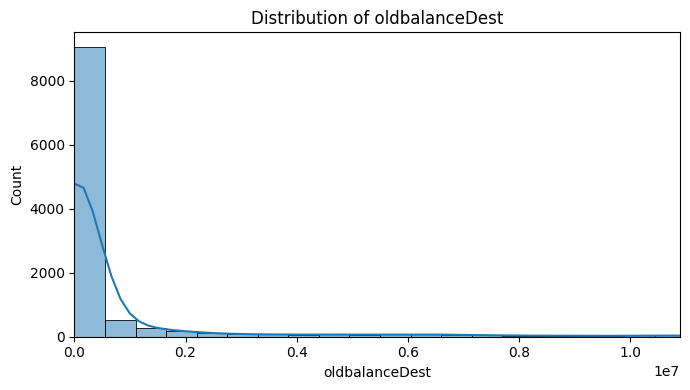

In [49]:
plt.figure(figsize=(7,4))
sns.histplot(df['oldbalanceDest'],bins=60,kde=True)
plt.xlim(0,df['oldbalanceDest'].quantile(0.98))
plt.title("Distribution of oldbalanceDest")
plt.tight_layout()
plt.show()

This graph highlights that low starting balances are common for destination accounts, and high balances are rare.

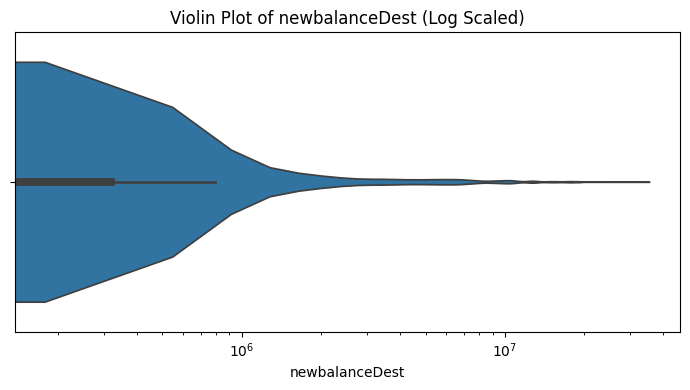

In [50]:
plt.figure(figsize=(7,4))
sns.violinplot(x=df['newbalanceDest'])
plt.xscale('log')
plt.title("Violin Plot of newbalanceDest (Log Scaled)")
plt.tight_layout()
plt.show()

This graph highlights that destination balances typically remain low, with only a small number of high-value cases.

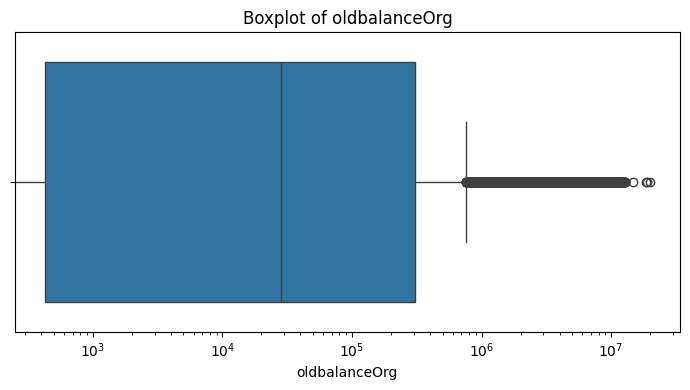

In [51]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['oldbalanceOrg'])
plt.xscale('log')
plt.title("Boxplot of oldbalanceOrg")
plt.tight_layout()
plt.show()

This plot shows that most sender accounts start with low balances, while a few have very high starting amounts.

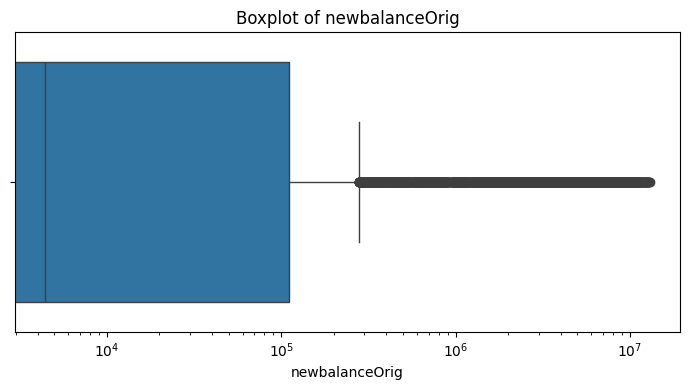

In [52]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['newbalanceOrig'])
plt.xscale('log')
plt.title("Boxplot of newbalanceOrig")
plt.tight_layout()
plt.show()

This graph highlights that most accounts end with low remaining balances, while high balances are rare.

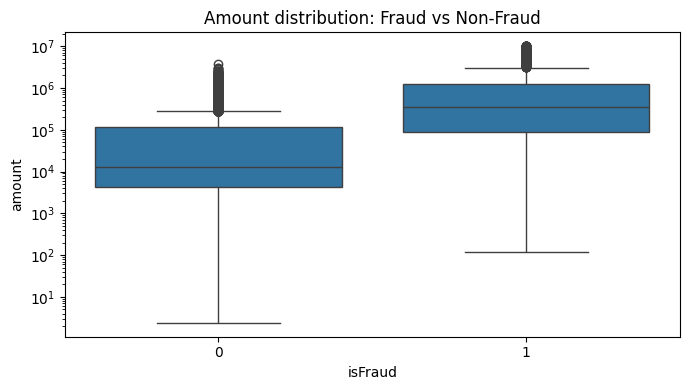

In [53]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df['isFraud'],y=df['amount'])
plt.yscale('log')
plt.title("Amount distribution: Fraud vs Non-Fraud")
plt.tight_layout()
plt.show()

This boxplot indicates that high-value transactions are more strongly associated with fraud.

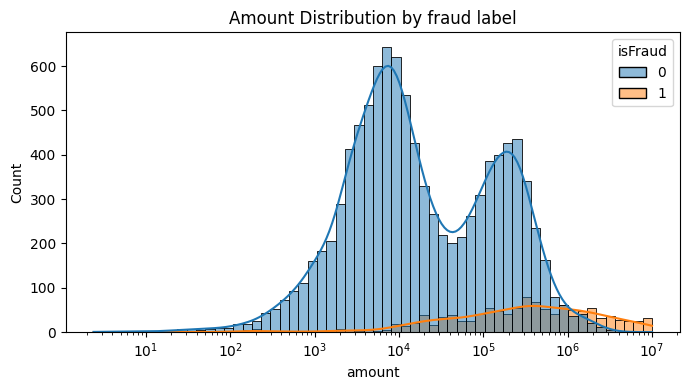

In [54]:
plt.figure(figsize=(7,4))
sns.histplot(x=df['amount'],hue=df['isFraud'],bins=60,kde=True,log_scale=True)
plt.title("Amount Distribution by fraud label")
plt.tight_layout()
plt.show()

The histogram highlights that large transaction amounts are more commonly associated with fraud.

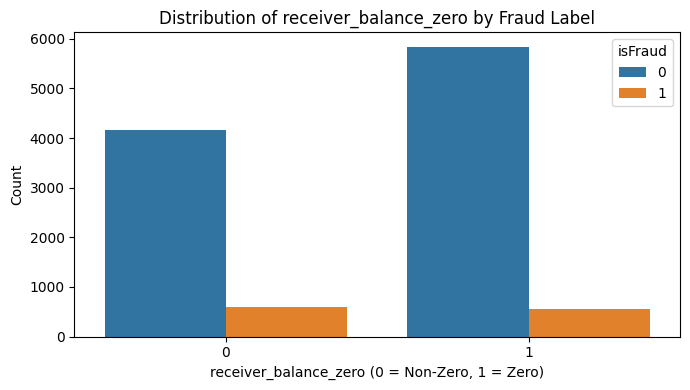

In [55]:
plt.figure(figsize=(7,4))
sns.countplot(x='receiver_balance_zero', hue='isFraud', data=df)
plt.title("Distribution of receiver_balance_zero by Fraud Label")
plt.xlabel("receiver_balance_zero (0 = Non-Zero, 1 = Zero)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The countplot reveals that zero-balance sender accounts are more frequently linked to fraud.

In [56]:
categoric_cols

['type']

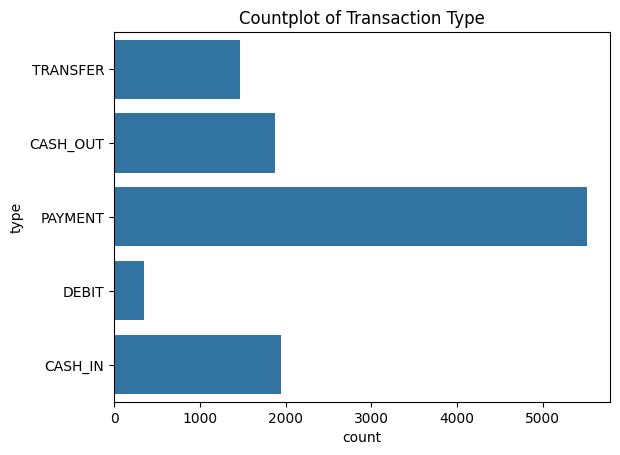

In [57]:
sns.countplot(df['type'])
plt.title("Countplot of Transaction Type")
plt.show()

This countplot shows the overall frequency of each transaction type.

In [58]:
df['type'].value_counts()

,count
type,
PAYMENT,5510
CASH_IN,1951
CASH_OUT,1871
TRANSFER,1464
DEBIT,346


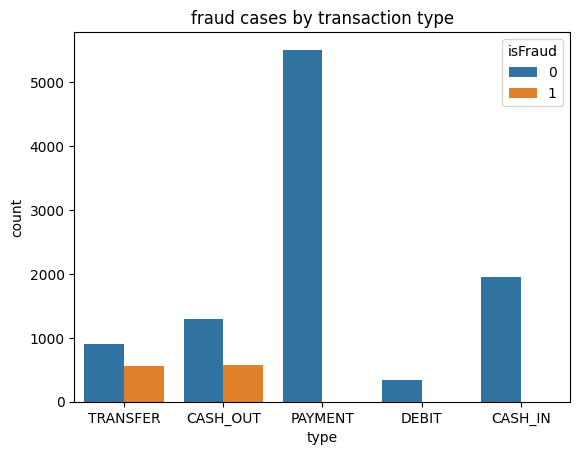

In [59]:
sns.countplot(x=df['type'],hue=df['isFraud'])
plt.title("fraud cases by transaction type")
plt.show()

shows Transfer and cash_out transactions are most prone to fraud.

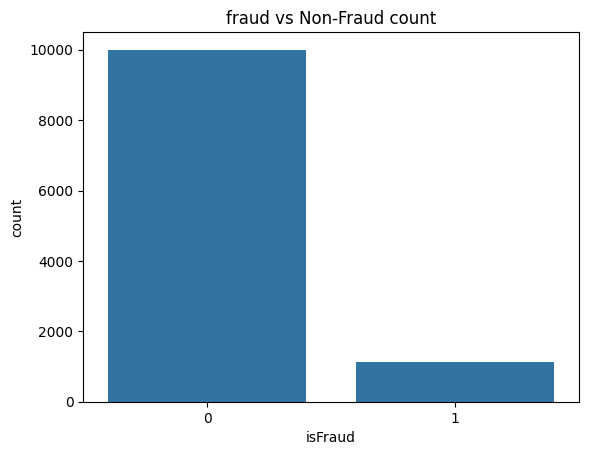

In [60]:
sns.countplot(x=df['isFraud'])
plt.title("fraud vs Non-Fraud count")
plt.show()

The countplot highlights that fraud cases are very few compared to normal transactions.

In [61]:
fraud_rate=df['isFraud'].mean()*100
print("Fraud Rate:",fraud_rate)

Fraud Rate: 10.249506372285047


Only 10.25% transactions are actually fraud----> Data is highly imbalanced.

In [62]:
df.dtypes

,0
type,object
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
isFraud,int64
sender_balance_diff,float64
receiver_balance_diff,float64
sender_balance_zero,int64


In [63]:
#Label Encoding
le=LabelEncoder()
df['type']=le.fit_transform(df['type'])

Converting categoric feature to numeric.

In [64]:
df['type'].dtype

dtype('int64')

In [65]:
#define X and y variable
X=df.drop(['isFraud'],axis=1)
y=df['isFraud']

In [66]:
X.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,sender_balance_diff,receiver_balance_diff,sender_balance_zero,receiver_balance_zero
0,4,181.0,181.0,0.0,0.0,0.0,181.0,0.0,1,1
1,1,181.0,181.0,0.0,21182.0,0.0,181.0,-21182.0,1,1
2,4,2806.0,2806.0,0.0,0.0,0.0,2806.0,0.0,1,1
3,1,2806.0,2806.0,0.0,26202.0,0.0,2806.0,-26202.0,1,1
4,4,20128.0,20128.0,0.0,0.0,0.0,20128.0,0.0,1,1


In [67]:
y.head()

,isFraud
0,1
1,1
2,1
3,1
4,1


In [68]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=123,stratify=y)

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
df.corr()['isFraud'].sort_values(ascending=False)

,isFraud
isFraud,1.000000
sender_balance_diff,0.487231
amount,0.435490
sender_balance_zero,0.358451
receiver_balance_diff,0.124020
type,0.060540
oldbalanceOrg,0.046445
newbalanceDest,-0.002864
oldbalanceDest,-0.056575
receiver_balance_zero,-0.059988


# Model Selection



1.   Logistic Regression: Used as a simple and interpretable baseline model.

1.   Random Forest: Handles complex data patterns better than linear models.



2.   XGBoost: Selected for high accuracy and efficient handling of complex patterns.


# Logistic Regression

In [71]:
from sklearn.linear_model import LogisticRegression

In [72]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score

In [73]:
lr=LogisticRegression()

In [74]:
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [75]:
y_pred=lr.predict(X_test_scaled)

In [76]:
print(confusion_matrix(y_test,y_pred))

[[2992    8]
 [ 102  241]]


In [77]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      3000
           1       0.97      0.70      0.81       343

    accuracy                           0.97      3343
   macro avg       0.97      0.85      0.90      3343
weighted avg       0.97      0.97      0.96      3343



In [78]:
accuracy_score(y_test,y_pred)*100

96.70954232725097

In [79]:
lr_probs=lr.predict_proba(X_test_scaled)[:,1]
lr_auc=roc_auc_score(y_test,lr_probs)
print("Logistic Regression AUC-ROC:",lr_auc)

Logistic Regression AUC-ROC: 0.9822837706511176


# Random Forest

In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [81]:
rf=RandomForestClassifier()

In [82]:
param={'n_estimators':[50,100,120,150],'bootstrap':[True,False],'max_depth':[3,5,7,9]}


In [83]:
gsc=GridSearchCV(estimator=rf,param_grid=param,scoring='accuracy')

In [84]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_depth': [3, 5, 7, 9],
                         'n_estimators': [50, 100, 120, 150]},
             scoring='accuracy')

In [85]:
gsc.best_params_

{'bootstrap': False, 'max_depth': 9, 'n_estimators': 120}

In [86]:
y_pred=gsc.best_estimator_.predict(X_test)

In [87]:
print(confusion_matrix(y_test,y_pred))

[[2991    9]
 [   7  336]]


In [88]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       0.97      0.98      0.98       343

    accuracy                           1.00      3343
   macro avg       0.99      0.99      0.99      3343
weighted avg       1.00      1.00      1.00      3343



In [89]:
accuracy_score(y_test,y_pred)*100

99.52138797487287

In [90]:
rf_probs=gsc.predict_proba(X_test)[:,1]
rf_auc=roc_auc_score(y_test,rf_probs)
print("Random Forest AUC-ROC:",rf_auc)

Random Forest AUC-ROC: 0.9985646258503402


# XGBoost

In [91]:
from xgboost.sklearn import XGBClassifier

In [92]:
xgb=XGBClassifier()

In [93]:
params={'n_estimators':[50,100,120,150],'learning_rate':[0.15,0.20,0.25,0.30],'min_child_weight':[3,6,9,12],'max_depth':[3,5,7,9]}

In [94]:
gsc=GridSearchCV(estimator=xgb,param_grid=params,scoring='accuracy')

In [95]:
gsc.fit(X_train,y_train)

GridSearchCV(estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     lea...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.15, 0.2, 0.25, 0.3],
                         'max_depth': [3, 5, 7, 9],
                         'min_child_weight': [3, 6, 9, 12],
                         'n_estimators': [50, 100, 120, 150]},
             scoring='accuracy')

In [96]:
gsc.best_params_

{'learning_rate': 0.25,
 'max_depth': 7,
 'min_child_weight': 3,
 'n_estimators': 50}

In [97]:
y_pred=gsc.best_estimator_.predict(X_test)

In [98]:
print(confusion_matrix(y_test,y_pred))

[[2987   13]
 [   4  339]]


In [99]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3000
           1       0.96      0.99      0.98       343

    accuracy                           0.99      3343
   macro avg       0.98      0.99      0.99      3343
weighted avg       1.00      0.99      0.99      3343



In [100]:
accuracy_score(y_test,y_pred)*100

99.49147472330242

In [101]:
xgb_probs=gsc.predict_proba(X_test)[:,1]
xgb_auc=roc_auc_score(y_test,xgb_probs)
print("XGBoost AUC_ROC:",xgb_auc)

XGBoost AUC_ROC: 0.9988989310009718


In [102]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=skf,
    scoring='f1'
)

print("F1 Scores:", scores)
print("Mean F1:", scores.mean())
print("Std Dev:", scores.std())

F1 Scores: [0.98245614 0.98030635 0.98268398 0.97345133 0.98461538]
Mean F1: 0.9807026361633829
Std Dev: 0.0038742389141169604


# feature importance analysis

In [103]:
feature_importance=pd.DataFrame({
    'Feature':X.columns,
    'Importance':gsc.best_estimator_.feature_importances_
})

feature_importance=feature_importance.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance)

                 Feature  Importance
6    sender_balance_diff    0.549884
3         newbalanceOrig    0.222590
1                 amount    0.059749
8    sender_balance_zero    0.046546
0                   type    0.041623
9  receiver_balance_zero    0.027227
7  receiver_balance_diff    0.016833
4         oldbalanceDest    0.016385
2          oldbalanceOrg    0.012635
5         newbalanceDest    0.006528


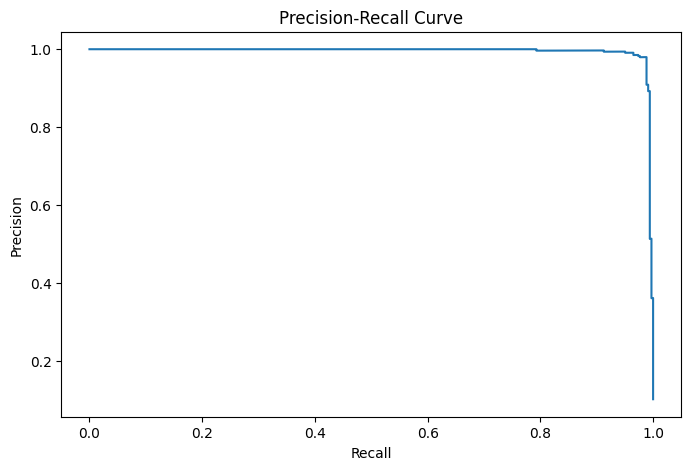

In [105]:
#Precision Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    xgb_probs
)

plt.figure(figsize=(8,5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

The Precision-Recall curve remains close to the top-right corner, indicating that the XGBoost model achieves both high precision and high recall, making it highly effective for fraud detection.

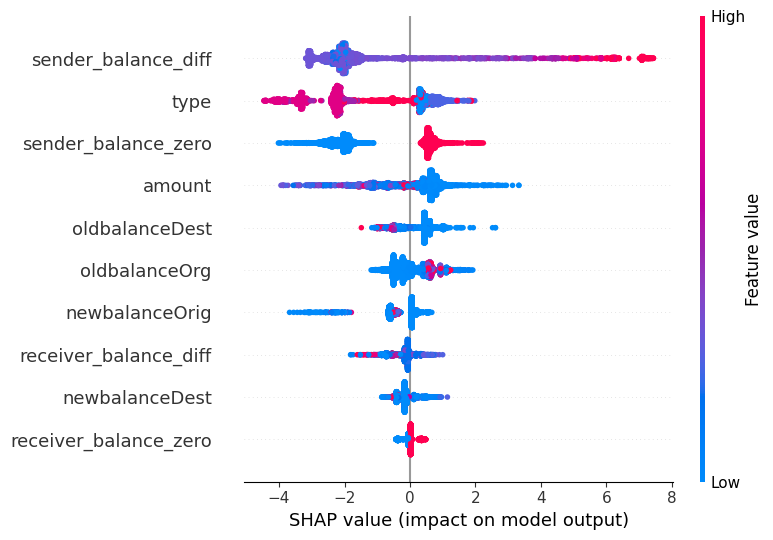

In [107]:
import shap

explainer = shap.TreeExplainer(gsc.best_estimator_)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

SHAP explainability revealed that engineered balance features contributed most to fraud detection, validating the effectiveness of feature engineering.

In [108]:
#save the model
import joblib
joblib.dump(xgb,'fraud_detection_xgboost.pkl')

['fraud_detection_xgboost.pkl']

# Conclusion

This project successfully developed a machine learning-based fraud detection system using transaction and balance-related features. Multiple models, including Logistic Regression, Random Forest, and XGBoost, were evaluated, with XGBoost delivering the best performance. The final model achieved 99% accuracy, 98% F1-score, 99% recall, and a ROC-AUC score of 99.89%, demonstrating excellent capability in identifying fraudulent transactions. Feature importance and SHAP analysis further revealed that sender balance-related features were the strongest indicators of fraud, providing both high predictive performance and model interpretability.